In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pd.set_option("display.max_columns",None)
sns.set_style("whitegrid")

In [3]:
df=pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.describe(include="all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [5]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [6]:
df.shape

(1000, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
df["Job"].unique()

array([2, 1, 3, 0])

In [9]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [10]:
df.drop(columns="Unnamed: 0",inplace=True)

In [11]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

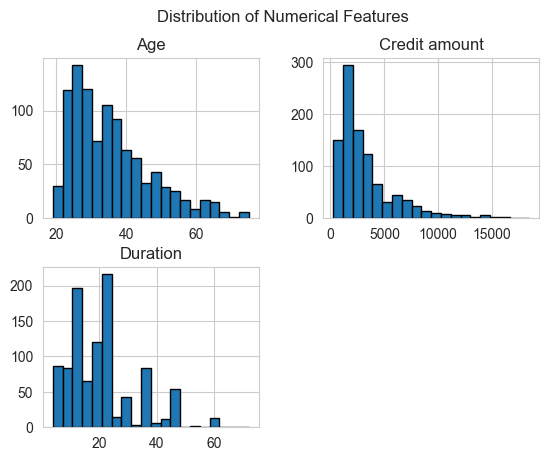

In [12]:
df[["Age","Credit amount","Duration"]].hist(bins=20,edgecolor="black")
plt.suptitle("Distribution of Numerical Features")
plt.show()

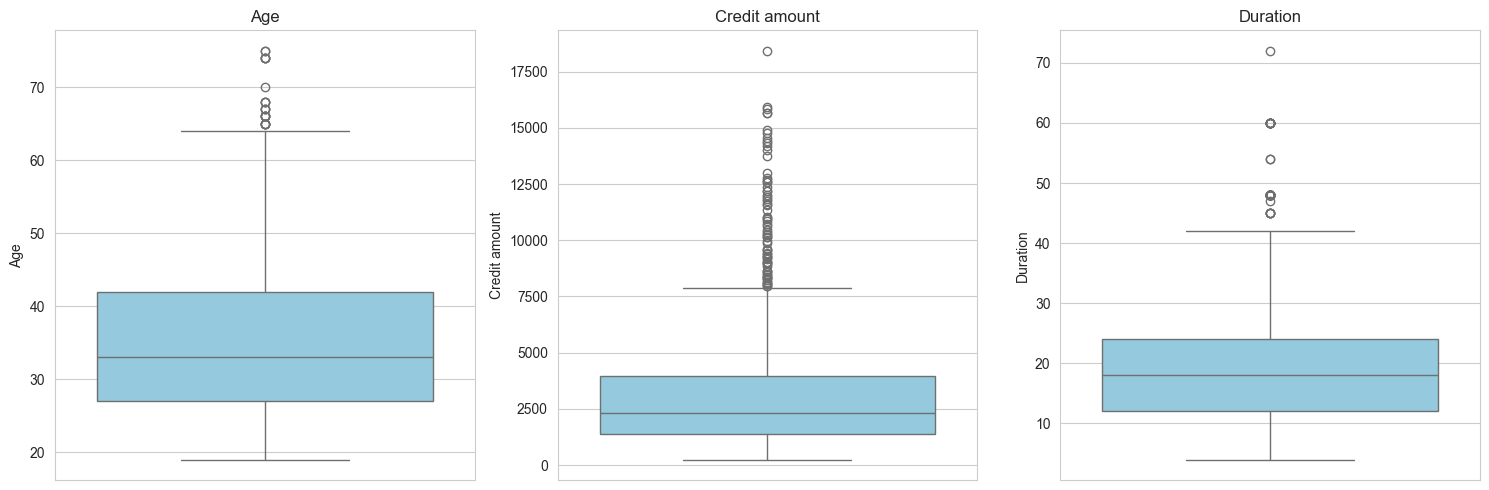

In [15]:
plt.figure(figsize=(15,5))
for i,col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()

In [27]:
categorical_cols=[["Sex","Job", 'Housing', 'Saving accounts', 'Checking account',"Purpose"]][0]

[['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']]
<class 'list'>


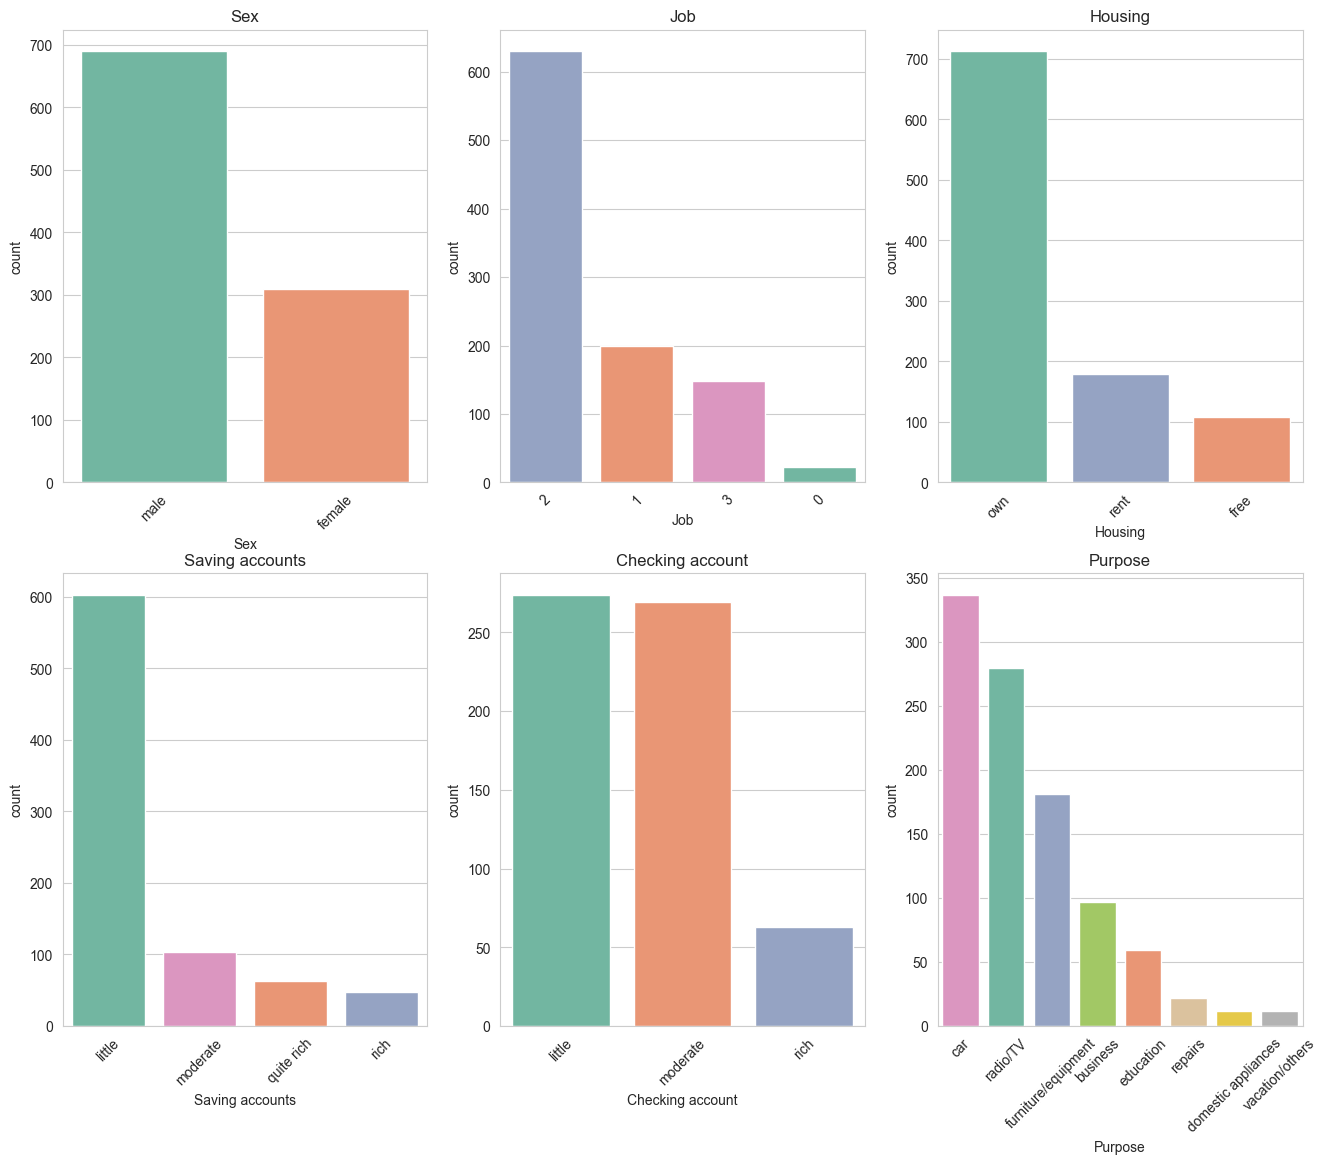

In [38]:
plt.figure(figsize=(16,20))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,order=df[col].value_counts().index,palette="Set2",hue=col,legend=False)
    plt.xticks(rotation=45)
    plt.title(col)
plt.show()

<Axes: >

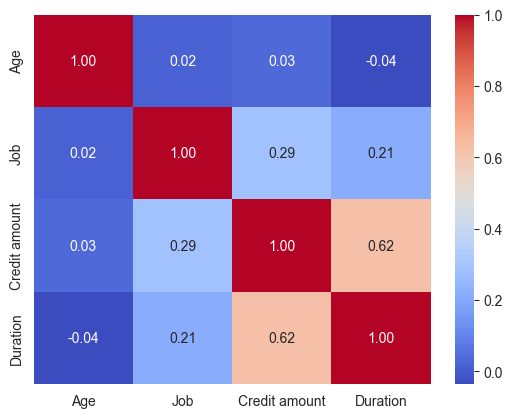

In [40]:
corr=df[["Age","Job","Credit amount","Duration",]].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt='.2f')

In [41]:
df.groupby("Job")["Credit amount"].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [42]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [43]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


<Axes: xlabel='Age', ylabel='Credit amount'>

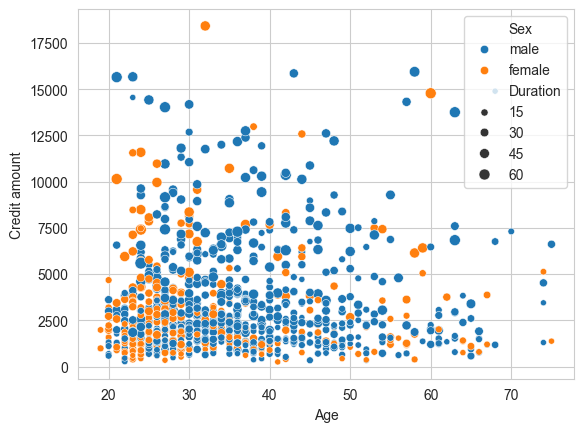

In [45]:
sns.scatterplot(df,x="Age",y="Credit amount",hue="Sex",size="Duration")

C:\Users\MAINAK\AppData\Local\Temp\ipykernel_20008\1440078180.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df,x="Saving accounts",y="Credit amount",palette="Set1")


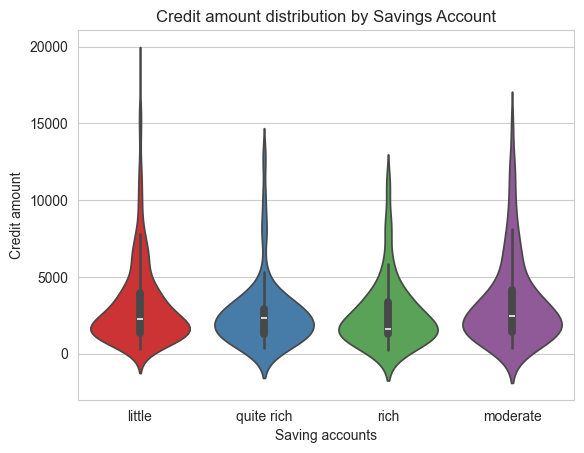

In [47]:
sns.violinplot(df,x="Saving accounts",y="Credit amount",palette="Set1")
plt.title("Credit amount distribution by Savings Account")
plt.show()

In [49]:
df["Risk"].value_counts(normalize=True)*100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

C:\Users\MAINAK\AppData\Local\Temp\ipykernel_20008\3293373019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk",y=cols,palette='Pastel1')
C:\Users\MAINAK\AppData\Local\Temp\ipykernel_20008\3293373019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk",y=cols,palette='Pastel1')
C:\Users\MAINAK\AppData\Local\Temp\ipykernel_20008\3293373019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Risk",y=cols,palette='Pastel1')


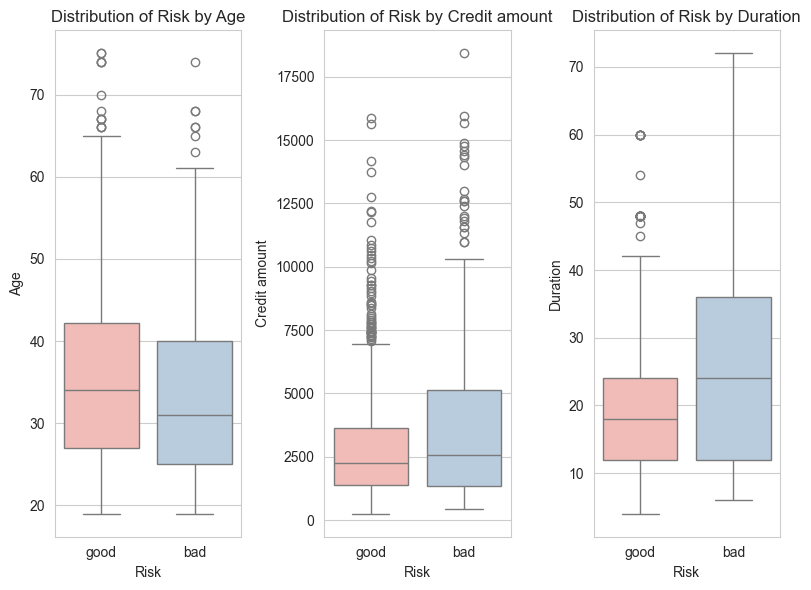

In [62]:
plt.figure(figsize=(8,6))
for i,cols in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x="Risk",y=cols,palette='Pastel1')
    plt.title(f"Distribution of Risk by {cols}")
plt.tight_layout()
plt.show()

In [64]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


In [65]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [72]:
features=list(["Age","Job","Sex","Housing","Credit amount","Saving accounts","Checking account","Duration"])
target=str("Risk")
cols=features+[target]

In [73]:
df_model=df[cols].copy()

In [74]:
df.sample(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
930,24,male,1,own,little,little,1747,24,furniture/equipment,good
75,66,male,3,free,little,little,1526,12,car,good
770,26,female,2,rent,NaN,little,2812,24,car,good
81,47,male,2,own,quite rich,NaN,1213,15,radio/TV,good
766,31,male,1,own,little,little,3108,30,furniture/equipment,bad


In [75]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [76]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")

In [77]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [79]:
le_dict={}
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le,f"{col}_encoder.pkl")

In [80]:
le_target=LabelEncoder()
df[target]=le_target.fit_transform(df[target])

In [81]:
joblib.dump(le_target,"target_encoder.pkl")

['target_encoder.pkl']

In [83]:
df_model.head()

,Age,Job,Sex,Housing,Credit amount,Saving accounts,Checking account,Duration,Risk
0,67,2,1,1,1169,4,0,6,good
1,22,2,0,1,5951,0,1,48,bad
2,49,1,1,1,2096,0,3,12,good
3,45,2,1,0,7882,0,0,42,good
4,53,2,1,0,4870,0,0,24,bad


In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X=df_model.drop(target,axis=1)
y=df[target]

In [92]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


In [89]:
def train_model(model,params_grid,X_train,y_train,X_test,y_test):
    grid = GridSearchCV(model,params_grid,cv=5,scoring=accuracy_score,n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model=grid.best_estimator_
    y_pred=best_model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    return best_model,acc,grid.best_params_




In [90]:
dt=DecisionTreeClassifier(random_state=42,class_weight="balanced")
dt_param_grid={"max_depth":[3,5,7,None],
               "min_samples_split":[2,5,10],
               "min_samples_leaf":[1,2,4]
}

In [93]:
best_dt,acc_dt,params_dt=train_model(dt,dt_param_grid,X_train,y_train,X_test,y_test)

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [94]:
print(best_dt,acc_dt,params_dt)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42) 0.675 {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [96]:
rf=RandomForestClassifier(random_state=42)
rf_param_grid={"max_depth":[3,5,7,None],
               "min_samples_split":[2,5,10],
               "n_estimators":[25,50,100],
               "max_features":["sqrt","log2"]
}

In [97]:
best_rf,acc_rf,params_rf=train_model(rf,rf_param_grid,X_train,y_train,X_test,y_test)
print(best_rf,acc_rf,params_rf)

RandomForestClassifier(max_depth=3, n_estimators=25, random_state=42) 0.73 {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 25}


c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [101]:
et=ExtraTreesClassifier(random_state=42,class_weight="balanced",n_jobs=-1)
et_param_grid={"max_depth":[3,5,7,None],
               "min_samples_split":[2,5,10],
               "n_estimators":[25,50,100],
               "max_features":["sqrt","log2"]
}

In [103]:
best_et,acc_et,params_et=train_model(et,et_param_grid,X_train,y_train,X_test,y_test)
print(f"best model:{best_rf},accuracy:{acc_rf},best parameters{params_rf}")

best model:RandomForestClassifier(max_depth=3, n_estimators=25, random_state=42),accuracy:0.73,best parameters{'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 25}


c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [104]:
xgb=XGBClassifier(random_state =42, eval_metric="logloss")
xgb_param_grid={"max_depth":[3,5,7,None],
             "n_estimators":[25,50,100],
             "learning_rate":[0.01,0.1,0.2],
             "subsample":[0.7,1],
             "colsample_bytree":[0.7,1]
               
}

In [105]:
best_xgb,acc_xgb,params_xgb=train_model(xgb,xgb_param_grid,X_train,y_train,X_test,y_test)
print(f"best model:{best_xgb},accuracy:{acc_xgb},best parameters{params_xgb}")

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


best model:XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.7,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.01, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=3, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=25, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...),accuracy:0.73,best parameters{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 25, 'subsample': 0.7}


In [106]:
joblib.dump(best_rf,"Best Random Credit Model.pkl")

['Best Random Credit Model.pkl']